In [ ]:
# Load saved models
import numpy as np

y_pred = np.load('y_pred.npy')
y_pred_balanced = np.load('y_pred_balanced.npy')
y_pred_smote = np.load('y_pred_smote.npy')

In [5]:
# Overall model evaluation summary
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

def evaluate_model(name, y_true, y_pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (1)": precision_score(y_true, y_pred, pos_label=1),
        "Recall (1)": recall_score(y_true, y_pred, pos_label=1),
        "F1-score (1)": f1_score(y_true, y_pred, pos_label=1)
    }

results = []

results.append(evaluate_model("Baseline", y_test, y_pred))
results.append(evaluate_model("Class Weight", y_test, y_pred_balanced))
results.append(evaluate_model("SMOTE", y_test, y_pred_smote))

results_df = pd.DataFrame(results)
results_df

,Model,Accuracy,Precision (1),Recall (1),F1-score (1)
0,Baseline,0.961877,0.300000,0.136364,0.187500
1,Class Weight,0.878299,0.185567,0.818182,0.302521
2,SMOTE,0.881965,0.183784,0.772727,0.296943


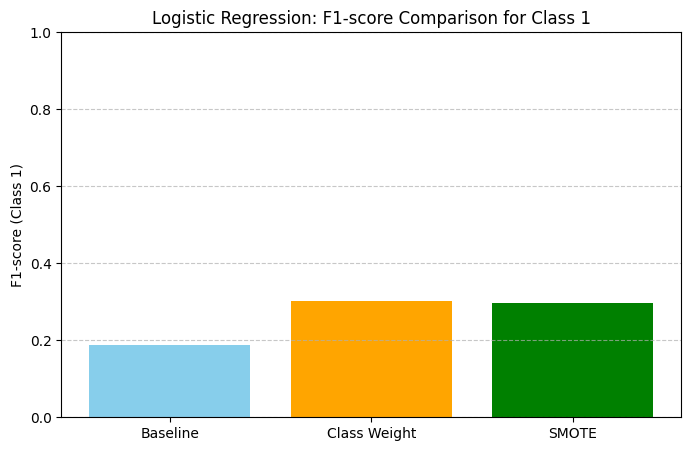

In [ ]:
# Visualization of F1-scores for Class 1
import matplotlib.pyplot as plt
import numpy as np

# Your F1-scores for Class 1 from your results
f1_scores = {
    'Baseline': 0.1875,
    'Class Weight': 0.302521,
    'SMOTE': 0.296943
}

# Create bar chart
plt.figure(figsize=(8,5))
plt.bar(f1_scores.keys(), f1_scores.values(), color=['skyblue', 'orange', 'green'])
plt.ylim(0, 1)
plt.ylabel('F1-score (Class 1)')
plt.title('Logistic Regression: F1-score Comparison for Class 1')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Save the figure
plt.savefig('f1_class1_comparison.png', dpi=300)
plt.show()

## Analysis

The baseline model achieved the highest accuracy but performed poorly in detecting bankrupt companies, as indicated by the very low recall 
(0.13). This shows that the model is biased towards the majority class.

The class-weighted model significantly improved recall (0.82), meaning it can correctly identify most bankrupt companies. Although accuracy decreased, 
this trade-off is acceptable for imbalanced classification problems.

The SMOTE model also improved recall (0.77), but performed slightly worse than the class-weighted model.

Overall, the class-weighted Logistic Regression model provides the best balance between performance and reliability.

# The class-weighted Logistic Regression model was selected as the final model due to its superior ability to detect minority 
# class instances while maintaining reasonable overall performance.


# In bankruptcy prediction, recall is more important than accuracy because failing to identify a bankrupt company can have serious financial consequences.
# The improvement in recall comes at the cost of lower precision, indicating more false positives.
